In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Практична робота №5")
print("Варіант 5 — Дніпро")
print("Михальчук Юліан, ІТ-42")

months = np.arange(1, 13)

precip = pd.Series([
    35, 32, 28, 33, 45, 58,
    55, 45, 33, 30, 36, 38
])

print("\nКількість опадів за 12 місяців:")
print(precip.values)

Практична робота №5
Варіант 5 — Дніпро
Михальчук Юліан, ІТ-42

Кількість опадів за 12 місяців:
[35 32 28 33 45 58 55 45 33 30 36 38]


## Завдання 1. Класифікація змінних за шкалою вимірювання

**Місто — номінальна шкала.**  
Назва міста є категорією без природного порядку. Для цієї змінної коректною мірою положення є мода. Середнє та медіана не мають змісту.

**Номер місяця — порядкова шкала.**  
Місяці мають природну послідовність від 1 до 12, але природного нуля, який означав би «відсутність місяця», немає. Тому в цій роботі розглядаю номер місяця як порядкову змінну. Для неї можна використовувати медіану та моду, але середнє не має достатньо змістовної інтерпретації.

Водночас номер місяця можна аргументувати й як інтервальну шкалу, оскільки календарні проміжки між сусідніми місяцями однакові. Саме тому класифікація цієї змінної не є повністю однозначною.

**Кількість опадів (мм) — відносна шкала.**  
0 мм означає реальну відсутність опадів, а відношення між значеннями має зміст. Для цієї змінної коректно використовувати середнє, медіану та моду.

In [2]:
# Завдання 2. Варіаційний ряд і частотний розподіл

# 1. Варіаційний ряд
sorted_precip = np.sort(precip.values)

print("Варіаційний ряд:")
print(sorted_precip)

# 2. Межі та 4 інтервали
min_value = precip.min()
max_value = precip.max()

bins = np.linspace(min_value, max_value, 5)

print("\nМінімум:", min_value)
print("Максимум:", max_value)
print("Межі 4 інтервалів:")
print(bins)

# 3. Частоти
frequency, edges = np.histogram(precip, bins=bins)

frequency_table = pd.DataFrame({
    "Інтервал": [
        f"[{edges[i]:.2f}; {edges[i+1]:.2f})"
        if i < len(frequency) - 1
        else f"[{edges[i]:.2f}; {edges[i+1]:.2f}]"
        for i in range(len(frequency))
    ],
    "Частота": frequency
})

print("\nЧастотна таблиця:")
print(frequency_table)

print("\nСума частот:", frequency.sum())

Варіаційний ряд:
[28 30 32 33 33 35 36 38 45 45 55 58]

Мінімум: 28
Максимум: 58
Межі 4 інтервалів:
[28.  35.5 43.  50.5 58. ]

Частотна таблиця:
         Інтервал  Частота
0  [28.00; 35.50)        6
1  [35.50; 43.00)        2
2  [43.00; 50.50)        2
3  [50.50; 58.00]        2

Сума частот: 12


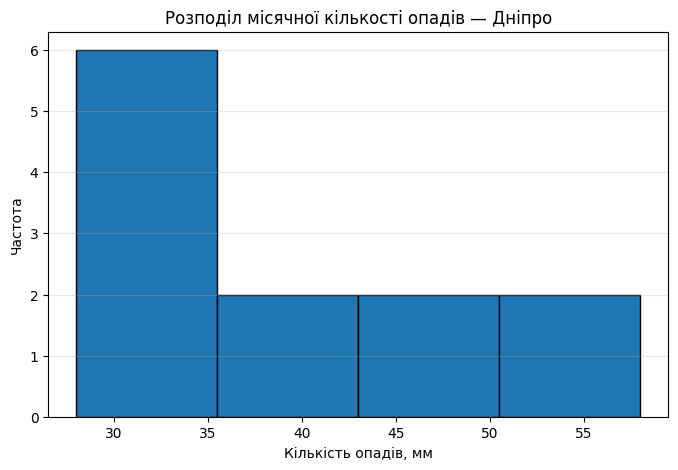

In [3]:
# Завдання 3. Гістограма частот

plt.figure(figsize=(8, 5))

plt.hist(
    precip,
    bins=bins,
    edgecolor="black"
)

plt.title("Розподіл місячної кількості опадів — Дніпро")
plt.xlabel("Кількість опадів, мм")
plt.ylabel("Частота")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [4]:
# Завдання 4. Описові характеристики

mean_value = precip.mean()
median_value = precip.median()
mode_value = precip.mode().tolist()

print("Середнє:", mean_value)
print("Медіана:", median_value)
print("Мода:", mode_value)

# Порівняння середнього та медіани
if mean_value > median_value:
    print("\nСереднє більше за медіану.")
    print("Це може свідчити про правосторонню асиметрію розподілу.")
elif mean_value < median_value:
    print("\nСереднє менше за медіану.")
    print("Це може свідчити про лівосторонню асиметрію розподілу.")
else:
    print("\nСереднє дорівнює медіані.")
    print("Розподіл близький до симетричного.")

Середнє: 39.0
Медіана: 35.5
Мода: [33, 45]

Середнє більше за медіану.
Це може свідчити про правосторонню асиметрію розподілу.


## Завдання 5. Зв'язок зі шкалою вимірювання

Кількість опадів у міліметрах належить до відносної шкали. Значення 0 мм має природний зміст — повну відсутність опадів. Також різниці та відношення між значеннями мають зміст: наприклад, 40 мм опадів у два рази більше, ніж 20 мм.

Тому для кількості опадів коректно використовувати всі три міри положення: середнє, медіану та моду.

Змінна «місто» належить до номінальної шкали. Назви міст є лише категоріями без числового порядку та відстані між значеннями. Тому для міста середнє та медіана не мають змісту, а з трьох мір положення коректною є лише мода.

In [5]:
# Доповнення до Завдання 4

q1 = precip.quantile(0.25)
q3 = precip.quantile(0.75)

print("Середнє:", precip.mean())
print("Медіана:", precip.median())
print("Мода:", precip.mode().tolist())
print("Q1:", q1)
print("Q3:", q3)

print("\nСереднє більше за медіану, тому розподіл має ознаки правосторонньої асиметрії.")

Середнє: 39.0
Медіана: 35.5
Мода: [33, 45]
Q1: 32.75
Q3: 45.0

Середнє більше за медіану, тому розподіл має ознаки правосторонньої асиметрії.


## Відповіді на контрольні питання

**1. Чим номінальна шкала відрізняється від порядкової?**  
Номінальна шкала використовується для категорій без природного порядку. Порядкова шкала має природний порядок значень, але відстані між ними не обов'язково однакові.

**2. Чим інтервальна шкала відрізняється від шкали відношень?**  
В інтервальній шкалі нуль є умовним, а в шкалі відношень нуль означає реальну відсутність величини. Тому для шкали відношень мають зміст порівняння типу «у два рази більше».

**3. Що таке варіаційний ряд?**  
Варіаційний ряд — це значення кількісної ознаки, впорядковані за зростанням або спаданням.

**4. Що показує гістограма частот?**  
Гістограма показує розподіл числових даних за інтервалами та кількість спостережень, що потрапляють у кожний інтервал.